<a href="https://colab.research.google.com/github/MuhammadUsmanAslam111/ai_intern_week04/blob/main/implementation_of_NN_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import tensorflow as tf
import numpy  as np
from tensorflow import keras
import matplotlib as plt

In [28]:
data=keras.datasets.fashion_mnist

In [29]:
(train_images,train_labels), (test_images,test_labels)=data.load_data()

In [30]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


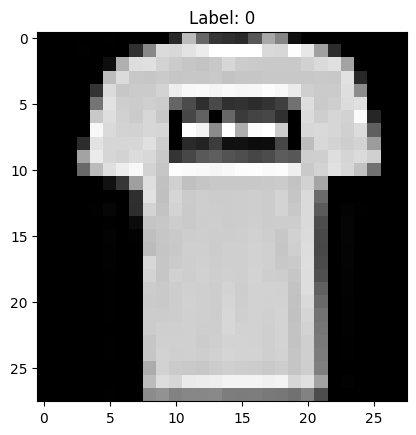

In [31]:
import matplotlib.pyplot as plt

plt.imshow(train_images[1], cmap='gray')
plt.title(f"Label: {train_labels[1]}")
plt.show()

In [32]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [33]:
for i, name in enumerate(class_names):
    print(i, "→", name)

0 → T-shirt/top
1 → Trouser
2 → Pullover
3 → Dress
4 → Coat
5 → Sandal
6 → Shirt
7 → Sneaker
8 → Bag
9 → Ankle boot


In [34]:
train_images=train_images/255
test_images=test_images/255

In [35]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax'),



])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [37]:
model.fit(train_images,train_labels,epochs=7)

Epoch 1/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7819 - loss: 0.6238
Epoch 2/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8615 - loss: 0.3880
Epoch 3/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8766 - loss: 0.3386
Epoch 4/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8827 - loss: 0.3189
Epoch 5/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8911 - loss: 0.2958
Epoch 6/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8990 - loss: 0.2714
Epoch 7/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9006 - loss: 0.2680


In [38]:
test_loss , test_acc =model.evaluate(test_images,test_labels)
print("test ACC: ",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8743 - loss: 0.3624
test ACC:  0.8726000189781189


In [40]:
prediction=model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


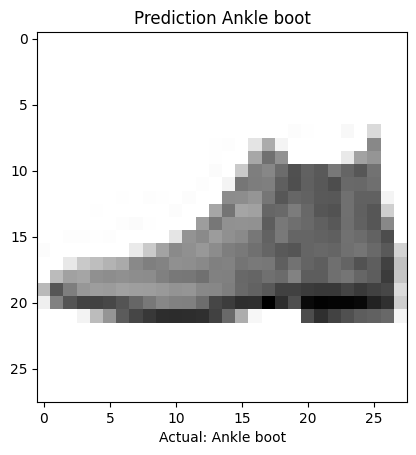

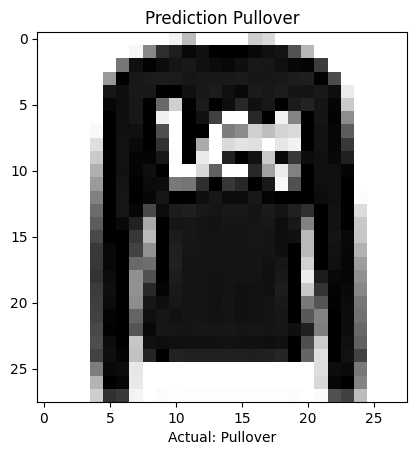

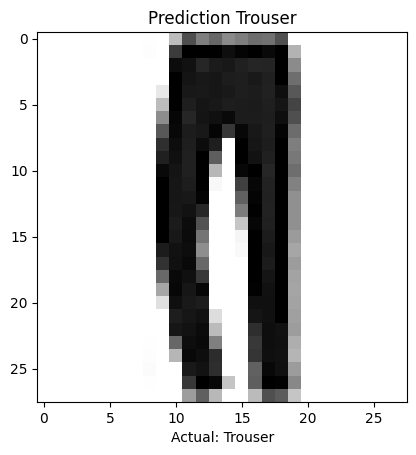

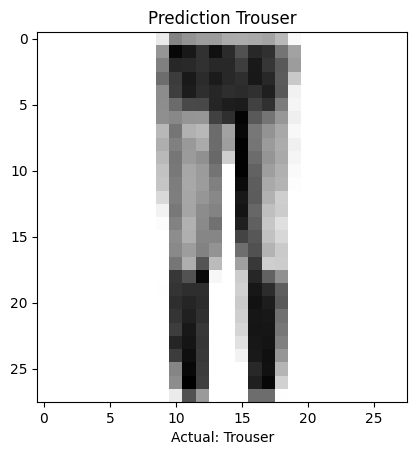

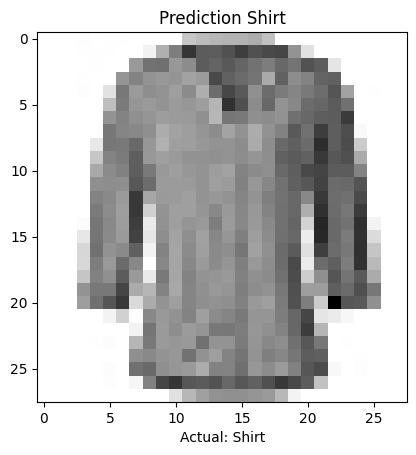

In [43]:
for i in range(5):
    plt.grid(False)
    plt.imshow(test_images[i], cmap=plt.cm.binary)
    plt.xlabel("Actual: " + class_names[test_labels[i]])
    plt.title("Prediction " + class_names[np.argmax(prediction[i])])
    plt.show()

In [44]:
model.save('best_model.h5')